In [44]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix


ImportError: cannot import name 'LogisticClassifier' from 'sklearn.linear_model' (C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\__init__.py)

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\PYTHON\DATA\weather_classification_data.csv")

In [3]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [4]:
df.tail()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy
13199,-5.0,38,0.0,92.0,overcast,1015.37,5,Autumn,10.0,mountain,Rainy


In [5]:
df.shape

(13200, 11)

In [6]:
df.columns 

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [7]:
df['Cloud Cover'].unique()

array(['partly cloudy', 'clear', 'overcast', 'cloudy'], dtype=object)

In [8]:
df['Season'].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

In [9]:
df.Location.unique()

array(['inland', 'mountain', 'coastal'], dtype=object)

In [10]:
df.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,13200.0,19.127576,17.386327,-25.00,4.0,21.00,31.0000,109.00
Humidity,13200.0,68.710833,20.194248,20.00,57.0,70.00,84.0000,109.00
Wind Speed,13200.0,9.832197,6.908704,0.00,5.0,9.00,13.5000,48.50
Precipitation (%),13200.0,53.644394,31.946541,0.00,19.0,58.00,82.0000,109.00
Atmospheric Pressure,13200.0,1005.827896,37.199589,800.12,994.8,1007.65,1016.7725,1199.21
UV Index,13200.0,4.005758,3.856600,0.00,1.0,3.00,7.0000,14.00
Visibility (km),13200.0,5.462917,3.371499,0.00,3.0,5.00,7.5000,20.00


In [12]:
df.describe(include='object')

,Cloud Cover,Season,Location,Weather Type
count,13200,13200,13200,13200
unique,4,4,3,4
top,overcast,Winter,inland,Rainy
freq,6090,5610,4816,3300


In [13]:
df.columns.tolist()

['Temperature',
 'Humidity',
 'Wind Speed',
 'Precipitation (%)',
 'Cloud Cover',
 'Atmospheric Pressure',
 'UV Index',
 'Season',
 'Visibility (km)',
 'Location',
 'Weather Type']

In [14]:
df.dtypes

Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object

In [15]:
df.duplicated().sum()

0

## TARGET COLUMN

In [16]:
df['Weather Type'].unique()

array(['Rainy', 'Cloudy', 'Sunny', 'Snowy'], dtype=object)

In [17]:
df['Weather Type'].value_counts()

Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: Weather Type, dtype: int64

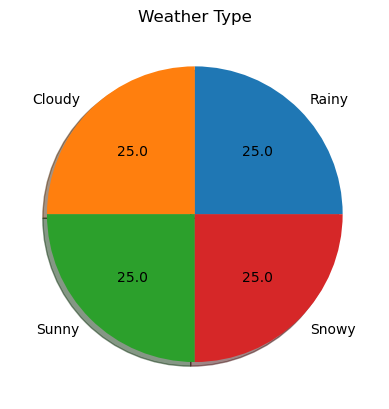

In [18]:

plt.pie(df.groupby(by=['Weather Type']).size(),labels=df['Weather Type'].unique(),shadow=True,autopct='%1.1f')
plt.title('Weather Type')
plt.show()


In [19]:
import seaborn as sns

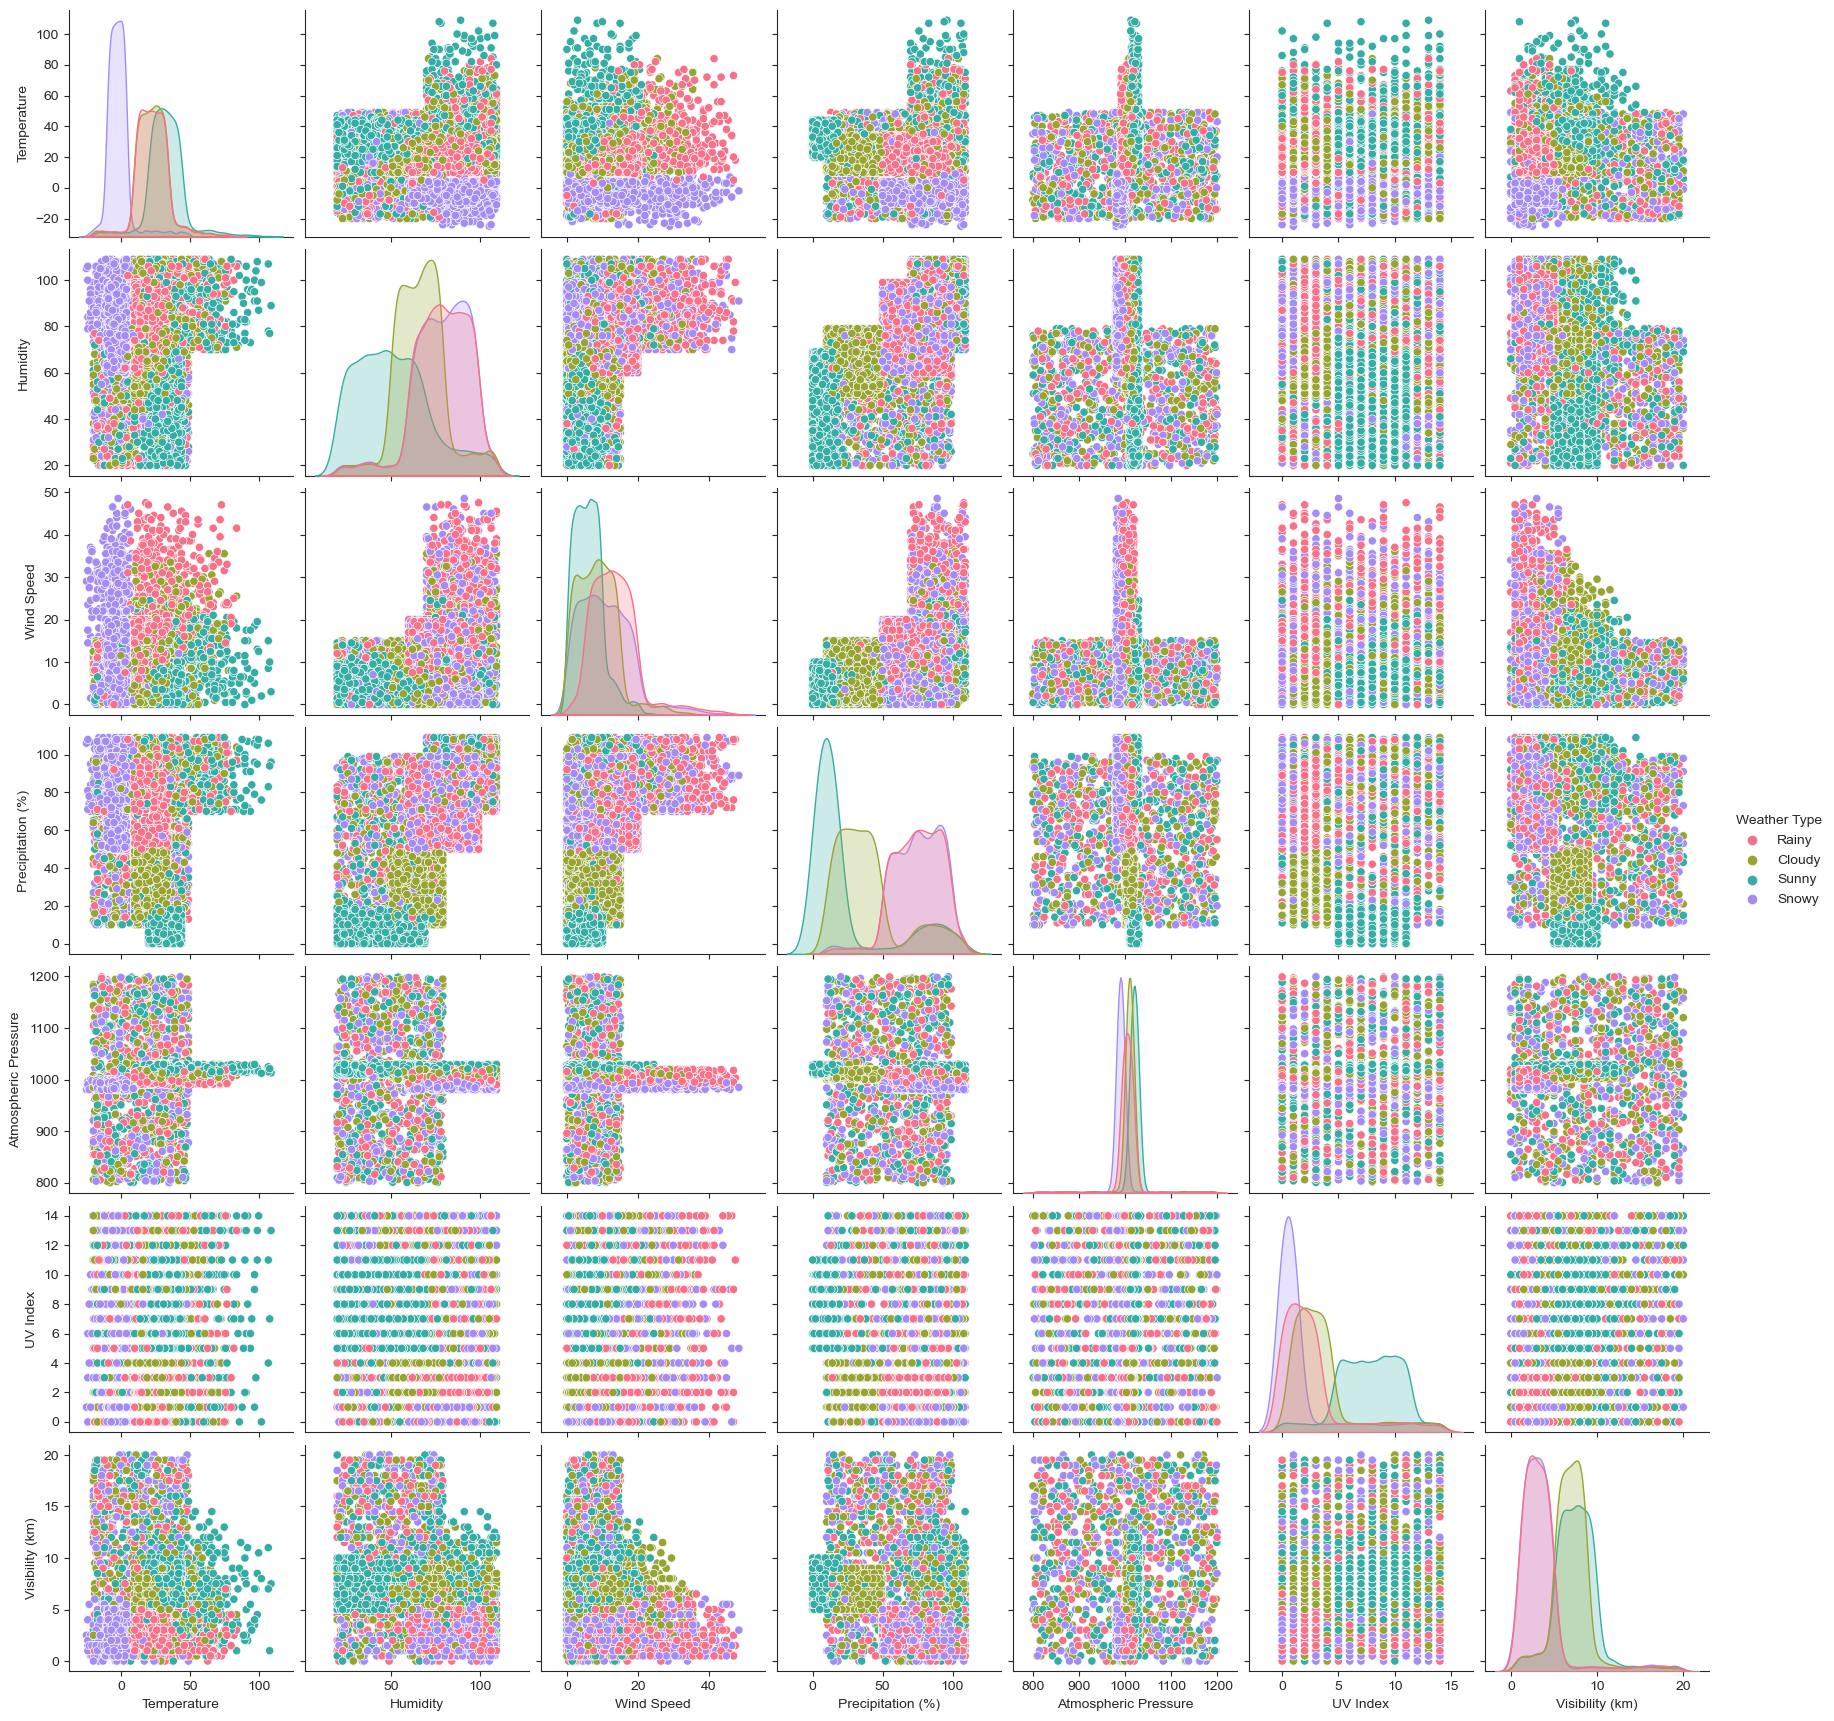

In [20]:
sns.set_style("ticks")
sns.pairplot(df[['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
        'Atmospheric Pressure', 'UV Index',
       'Visibility (km)', 'Weather Type']],hue='Weather Type',diag_kind="kde",kind="scatter",palette="husl")
plt.show()


In [21]:
df[['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
        'Atmospheric Pressure', 'UV Index',
       'Visibility (km)', 'Weather Type']].corr()


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
Temperature,1.000000,-0.207969,-0.070022,-0.287206,0.209188,0.374773,0.250751
Humidity,-0.207969,1.000000,0.406079,0.638631,-0.120653,-0.342694,-0.479969
Wind Speed,-0.070022,0.406079,1.000000,0.443770,-0.077757,-0.068147,-0.311828
Precipitation (%),-0.287206,0.638631,0.443770,1.000000,-0.177444,-0.291601,-0.457444
Atmospheric Pressure,0.209188,-0.120653,-0.077757,-0.177444,1.000000,0.154128,0.120182
UV Index,0.374773,-0.342694,-0.068147,-0.291601,0.154128,1.000000,0.362922
Visibility (km),0.250751,-0.479969,-0.311828,-0.457444,0.120182,0.362922,1.000000


<AxesSubplot:>

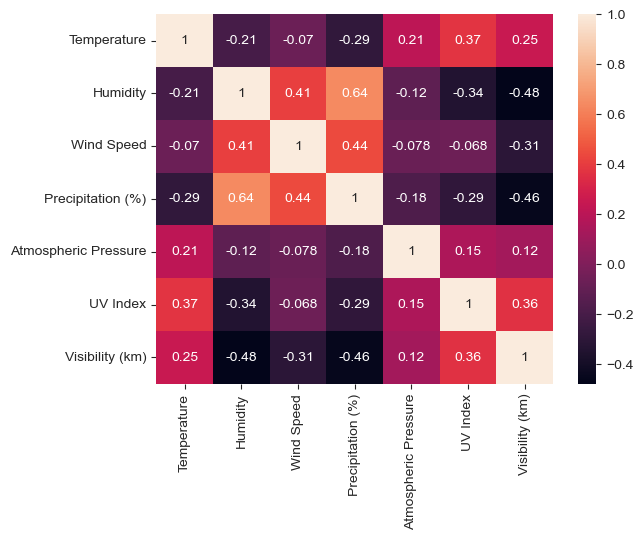

In [22]:
sns.heatmap(df[['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
        'Atmospheric Pressure', 'UV Index',
       'Visibility (km)', 'Weather Type']].corr(), annot = True)

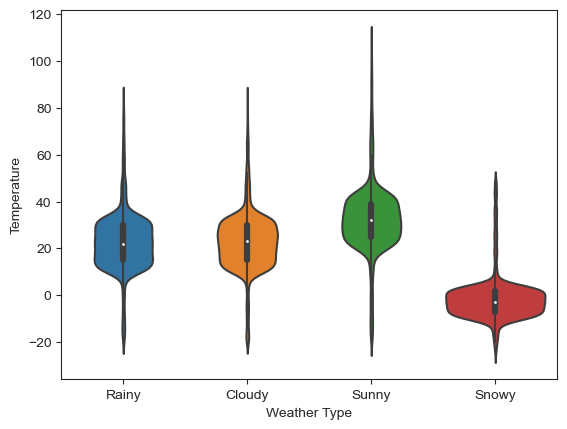

In [23]:
sns.violinplot(x="Weather Type",y="Temperature", data=df)
plt.show()

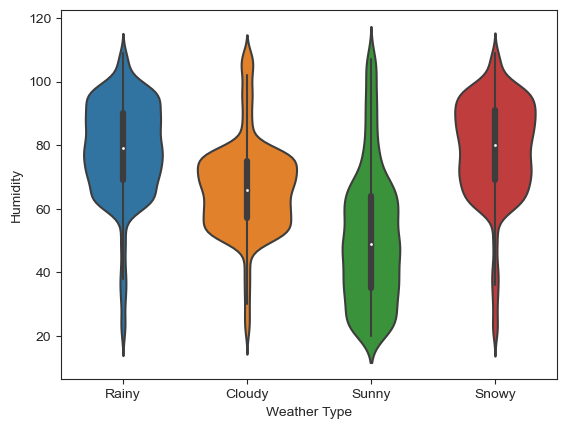

In [24]:
sns.violinplot(x="Weather Type",y='Humidity', data=df)
plt.show()

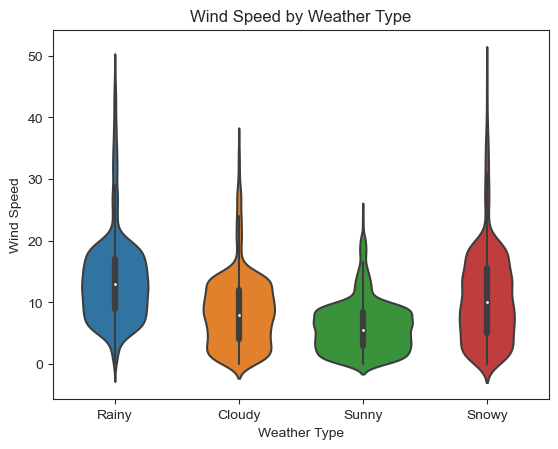

In [25]:
sns.violinplot(x="Weather Type",y ='Wind Speed', data=df)
plt.title('Wind Speed by Weather Type')
plt.show()

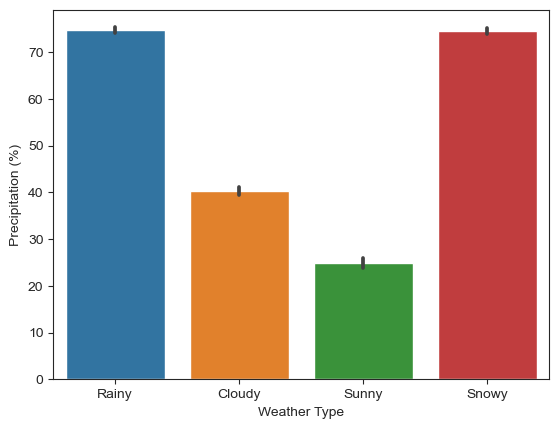

In [26]:
sns.barplot(x = 'Weather Type',  y= 'Precipitation (%)',data=df)
plt.show()


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 3)

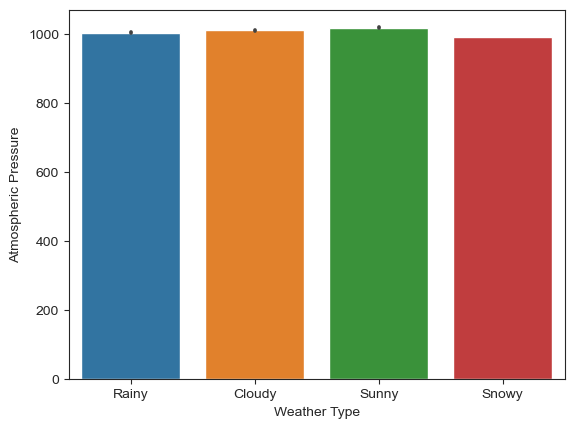

In [29]:
sns.barplot(x = 'Weather Type',  y= 'Atmospheric Pressure',data=df)
plt.show()


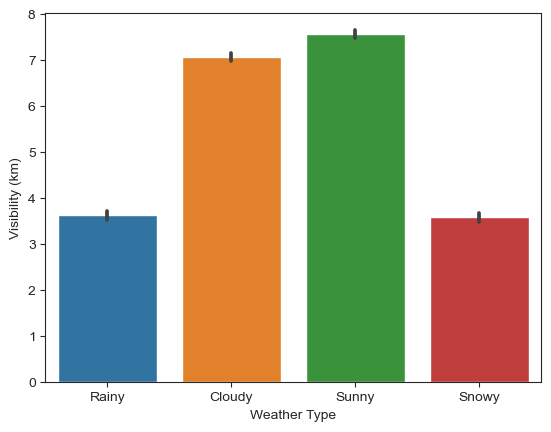

In [30]:
 sns.barplot(x = 'Weather Type',  y= 'Visibility (km)',data=df)
plt.show()

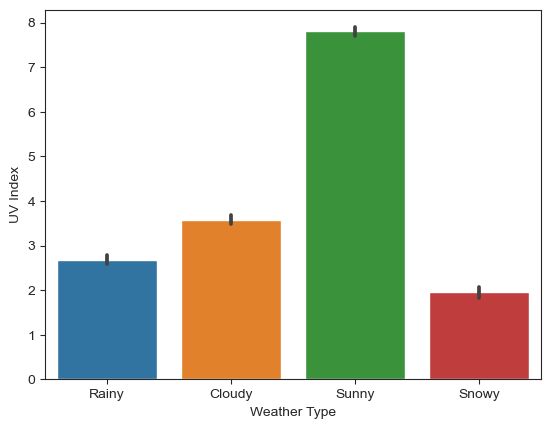

In [31]:
sns.barplot(x = 'Weather Type',  y= 'UV Index',data=df)
plt.show()

In [32]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [33]:
df['Cloud Cover'].unique()

array(['partly cloudy', 'clear', 'overcast', 'cloudy'], dtype=object)

In [34]:
l=LabelEncoder()
df['Cloud Cover'] = l.fit_transform(df['Cloud Cover'])
df['Season'] = l.fit_transform(df['Season'])
df['Location'] =l.fit_transform(df['Location'])
df['Weather Type'] =l.fit_transform(df['Weather Type'])

In [35]:
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,2,1003.15,1,2,1.0,2,1
13196,-1.0,76,3.5,23.0,1,1067.23,1,3,6.0,0,2
13197,30.0,77,5.5,28.0,2,1012.69,3,0,9.0,0,0
13198,3.0,76,10.0,94.0,2,984.27,0,3,2.0,1,2


In [36]:
X= df.iloc[:, :-1].values
y= df.iloc[:,-1].values

In [37]:
print(X)
print(y)


[[14.  73.   9.5 ...  3.   3.5  1. ]
 [39.  96.   8.5 ...  1.  10.   1. ]
 [30.  64.   7.  ...  1.   5.5  2. ]
 ...
 [30.  77.   5.5 ...  0.   9.   0. ]
 [ 3.  76.  10.  ...  3.   2.   1. ]
 [-5.  38.   0.  ...  0.  10.   2. ]]
[1 0 3 ... 0 2 1]


In [38]:

X_trainval, X_test, y_trainval, y_test = train_test_split(
 X, y, random_state=0)
# split train+validation set into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
 X_trainval, y_trainval, random_state=1)
print("Size of training set: {} size of validation set: {} size of test set:"
 " {}\n".format(X_train.shape[0], X_valid.shape[0], X_test.shape[0]))


Size of training set: 7425 size of validation set: 2475 size of test set: 3300



In [39]:
param_grid1 = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}
print("Parameter grid:\n{}".format(param_grid1))


Parameter grid:
{'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


In [40]:
grid_search1 = GridSearchCV(SVC(), param_grid, cv=5)
grid_search1.fit(X_train, y_train)
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))


Best parameters: {'C': 10, 'gamma': 0.001}
Best cross-validation score: 0.90


In [47]:
logreg= LogisticRegression()
fit=logreg.fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))


Training set score: 0.841
Test set score: 0.849


C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [61]:
param_grid2 = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
print("List of grids:\n{}".format(param_grid2))

List of grids:
{'C': [0.001, 0.01, 0.1, 1, 10, 100]}


In [63]:
grid_search2 = GridSearchCV(logreg,param_grid2)
grid_search2.fit(X_train, y_train)
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))

C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Best parameters: {'C': 10}
Best cross-validation score: 0.85


C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
maxdepth = {'max_depth': [3, 4,5, 7, 10, 15]}
print("List of grids:\n{}".format(maxdepth))

List of grids:
{'max_depth': [3, 4, 5, 7, 10, 15]}


In [86]:
DT=DecisionTreeClassifier(max_depth =7, random_state=0)
DT.fit(X_train, y_train)
print("Training set score: {:.3f}".format(DT.score(X_train, y_train)))
print("Test set score: {:.3f}".format(DT.score(X_test, y_test)))



Training set score: 0.936
Test set score: 0.916


In [106]:
RF = RandomForestClassifier(n_estimators=10 , random_state=0)
RF.fit(X_train, y_train)
print("Training set score: {:.3f}".format(RF.score(X_train, y_train)))
print("Test set score: {:.3f}".format(RF.score(X_test, y_test)))


Training set score: 0.998
Test set score: 0.916


In [139]:
predRF= RF.predict(X_test)
predRF

array([1, 2, 0, ..., 2, 1, 0])

In [108]:
from sklearn.ensemble import GradientBoostingClassifier
gbrt=GradientBoostingClassifier()
gbrt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 0.957
Accuracy on test set: 0.921


## BEST MODEL

In [111]:
gbrt2 = GradientBoostingClassifier(random_state=0, max_depth=5)
gbrt2.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gbrt2.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt2.score(X_test, y_test)))

Accuracy on training set: 0.995
Accuracy on test set: 0.923


In [120]:
pred=gbrt2.predict(X_test)
pred

array([1, 2, 0, ..., 2, 1, 0])

In [130]:
y_test

array([1, 2, 0, ..., 2, 1, 0])

In [121]:
confusion = confusion_matrix(y_test, pred)
print("Confusion matrix:\n{}".format(confusion))

Confusion matrix:
[[739  51  20  19]
 [ 27 772  18  12]
 [ 13  13 777  25]
 [ 21  19  17 757]]


In [122]:
import mglearn

Text(0.5, 1.0, 'Confusion Matrix')

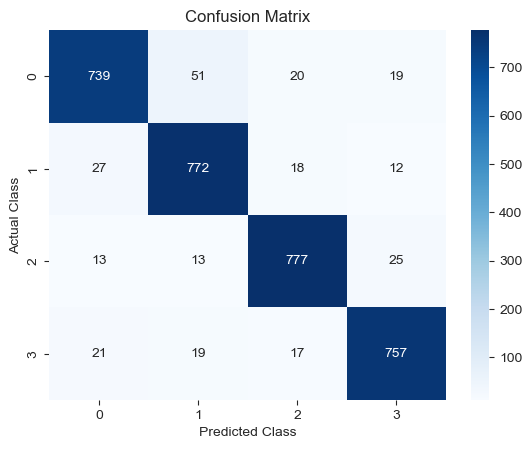

In [127]:
sns.heatmap(confusion, annot=True, cmap='Blues',fmt='d')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

In [133]:
from sklearn.metrics import f1_score
print("f1 score gradient: {:.2f}".format(
 f1_score(y_test, pred, average ='macro')))

f1 score gradient: 0.92


In [134]:
from sklearn.metrics import f1_score
print("f1 score gradient: {:.2f}".format(
 f1_score(y_test, pred, average ='weighted')))

f1 score gradient: 0.92


f1 score gradient: 0.92
